In [1]:
import os
import pickle
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.preprocessing.image import img_to_array, load_img
from tensorflow.keras.applications.resnet50 import preprocess_input

I0000 00:00:1782843230.668708   62505 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1782843230.669806   62505 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1782843230.743320   62505 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1782843232.204044   62505 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONE

In [2]:
BASE = "../dataset"
images_dir = os.path.join(BASE, "Images")
captions_path = os.path.join(BASE, "captions.txt")

df = pd.read_csv(captions_path)

(np.float64(-0.5), np.float64(374.5), np.float64(499.5), np.float64(-0.5))

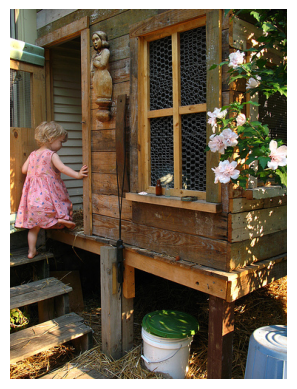

In [3]:
sample = df.iloc[0]
path = os.path.join(images_dir, sample["image"])
img = Image.open(path)
plt.imshow(img)
plt.axis("off")

In [4]:
cnn = ResNet50(
    weights="imagenet",
    include_top=False,
    pooling="avg"
)

E0000 00:00:1782843234.947270   62505 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1782843234.967363   62505 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [5]:
def extract_features(img_path):
    img = load_img(img_path, target_size=(224, 224))
    img = img_to_array(img)
    img = np.expand_dims(img, axis=0)
    img = preprocess_input(img)
    return cnn.predict(img, verbose=0).flatten()

features = {}
for img_name in df["image"].unique():
    img_path = os.path.join(images_dir, img_name)
    features[img_name] = extract_features(img_path)

print("Feature shape:", features[img_name].shape)

Feature shape: (2048,)


In [6]:
os.makedirs("../model", exist_ok=True)
pickle.dump(
    features,
    open("../model/features.pkl", "wb")
)
print("Features saved to model/features.pkl")

Features saved to model/features.pkl
